# Time Series Data Cleaning

This notebook performs data cleaning of financial time series data, namely steel prices on an exchange over a one week period, which come from two different sources, Wakands and Buranda.

It then compares 3 different autoregressive (AR) models and compares their accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas.tseries.offsets as pdto
import json

In [2]:
steel_prices_df = pd.read_csv("steel_prices_with_exchange.csv", index_col=0, parse_dates=True)
print(steel_prices_df.head(5))

                                       val   source
2020-09-01 00:00:00.135012414  2070.000000  Wakanda
2020-09-01 00:00:01.491934077  2400.000000  Buranda
2020-09-01 00:05:00.733157824  2430.000000  Buranda
2020-09-01 00:05:01.871980801  1950.000000  Wakanda
2020-09-01 00:10:00.937959087  2893.641781  Buranda


In [3]:
# check for missing values
total_nans = sum(np.isnan(steel_prices_df['val']))
total_nans

273

In [4]:
proportion_missing = total_nans/len(steel_prices_df['val'])
missing_as_percentage = "{:.2%}".format(proportion_missing)
print(missing_as_percentage)

6.77%


First I visualise the time series data over the entire week, the first hour, and the first 10 datapoints.

In [5]:
def plot_time_series(series: pd.Series) -> None:
    
    ylabel = 'val'
    plt.figure(figsize = (15,15))
    plt.subplot(3, 1, 1)
    plt.plot(series)
    plt.title('Steel price over the week')
    plt.ylabel(ylabel)
    plt.subplot(3, 1, 2)
    first_hour = series[series.index < pd.Timestamp("2020-09-01") + pdto.Hour(1)]
    plt.plot(first_hour)
    plt.title('Steel price over the first hour')
    plt.ylabel(ylabel)
    plt.subplot(3, 1, 3)
    plt.plot(series[:10])
    plt.title('Steel price over the first 10 price entries')
    plt.ylabel(ylabel)

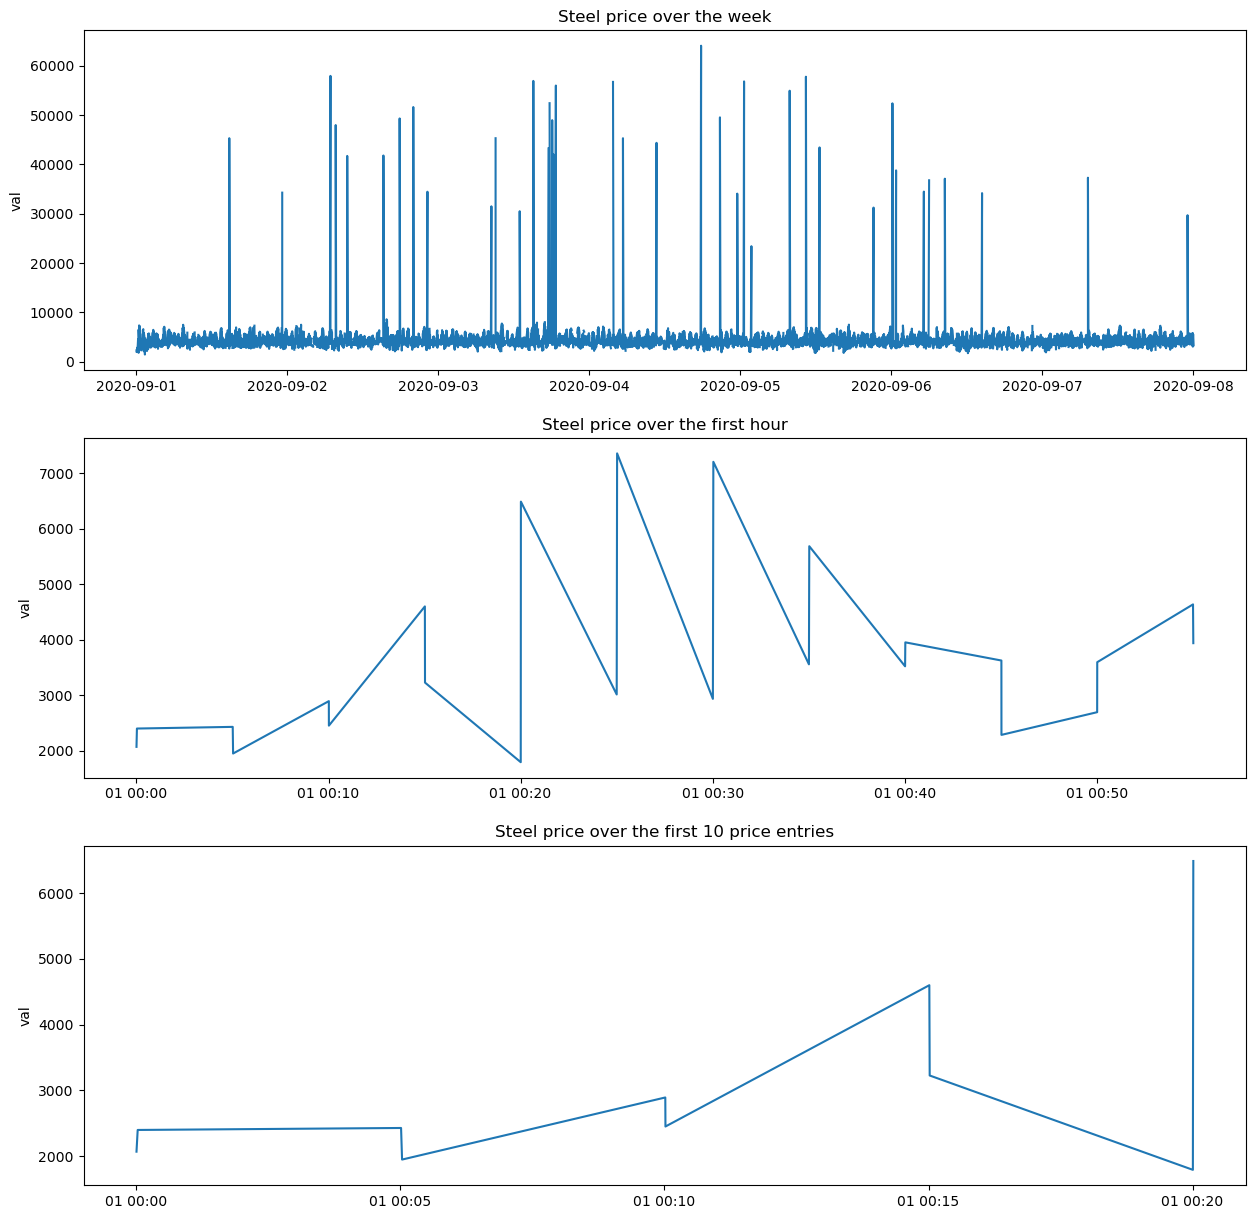

In [6]:
val = steel_prices_df['val']
plot_time_series(val)

We can see from the above that the data from the two different sources arrive very close to each other and are quite different in magnitude.

Below I check for outliers. I compute the ower quartile (LQ), upper quartile (UQ) and interquartile range (IQR) and define outliers as:

UQ + 1.5 * IQR

LQ - 1.5 * IQR

In [7]:
lq = np.nanquantile(steel_prices_df['val'], 0.25)
uq = np.nanquantile(steel_prices_df['val'], 0.75)
iqr = uq-lq

In [8]:
lower_limit = lq - 1.5*iqr
upper_limit = uq + 1.5*iqr
raw_outlier_index  = (steel_prices_df['val'] < lower_limit) | (steel_prices_df['val'] > upper_limit)

In [9]:
num_outliers =  raw_outlier_index.sum()
num_outliers

56

In [10]:
steel_prices_df_no_outliers = steel_prices_df.copy()

# replacing every location of an outlier in the val column with np.NaN
steel_prices_df_no_outliers.loc[raw_outlier_index, 'val'] = np.NaN

In [11]:
# remove entries with NaNs
steel_prices_df_clean = steel_prices_df_no_outliers.copy().dropna()


Next I resample the data to be every 5 minutes.

In [12]:
reindexed_data = steel_prices_df_clean.resample('5min').bfill()

reindexed_data.head(4)

,val,source
2020-09-01 00:00:00,2070.000000,Wakanda
2020-09-01 00:05:00,2430.000000,Buranda
2020-09-01 00:10:00,2893.641781,Buranda
2020-09-01 00:15:00,4599.562373,Wakanda


We can see that the sources are different in this dataframe.

#### Time Series Prediction

Now that we have consistently intervaled data, we can think of each datapoint as existing at a given regular time index, $t \in \mathbb{N}$, where $\mathbb{N}$ is defined as the non-negative integers.

A potential time series auto-regressive (AR) model for predicting the steel price, $\hat{y}_t$, at time index $t$ using the real observed data $y_{t-1}$ and $y_{t-2}$ for prior time indices $t-1$ and $t-2$, respectively is given by:

$$
\hat{y}_t = 3426 + 0.115y_{t-1} + 0.079y_{t-2}
$$

In [13]:
def add_ar2_predictions_to_df(df: pd.DataFrame, ar: list):
    '''
    Adds a column of predictions from an ar(2) model given input dataframe of observed
    values and ar model parameter values
    '''
    values = df.loc[:,'val']
    df['prediction'] = ar[0] + ar[1] * values.shift(1) +  ar[2] * values.shift(2)
    
    # Set the first two predictions to be the given prices
    df.iloc[0, 2] = values.iloc[0]
    df.iloc[1, 2] = values.iloc[1]
    return df

ar_parameters = [3426, 0.115, 0.079]
add_ar2_predictions_to_df(reindexed_data, ar_parameters)

,val,source,prediction
2020-09-01 00:00:00,2070.000000,Wakanda,2070.000000
2020-09-01 00:05:00,2430.000000,Buranda,2430.000000
2020-09-01 00:10:00,2893.641781,Buranda,3868.980000
2020-09-01 00:15:00,4599.562373,Wakanda,3950.738805
2020-09-01 00:20:00,1793.946032,Buranda,4183.547374
...,...,...,...
2020-09-07 23:40:00,3500.644591,Buranda,4176.528915
2020-09-07 23:45:00,5432.015717,Wakanda,4153.268701
2020-09-07 23:50:00,5756.125171,Wakanda,4327.232730
2020-09-07 23:55:00,3053.716051,Buranda,4517.083636


#### Partitioning by Source and Predicting

Next I generate predictions assuming the two sources follow different models

In [14]:
cleaned_data_copy = steel_prices_df_clean.copy()
cleaned_data_wakanda = steel_prices_df_clean[steel_prices_df_clean.loc[:, 'source'] == 'Wakanda']
cleaned_data_buranda = steel_prices_df_clean[steel_prices_df_clean.loc[:, 'source'] =='Buranda']

In [15]:
cleaned_data_wakanda.head(5)

,val,source
2020-09-01 00:00:00.135012414,2070.000000,Wakanda
2020-09-01 00:05:01.871980801,1950.000000,Wakanda
2020-09-01 00:10:01.117040787,2452.294187,Wakanda
2020-09-01 00:15:00.924775968,4599.562373,Wakanda
2020-09-01 00:20:00.848571954,6486.849217,Wakanda


Next for both cleaned_data_wakanda and cleaned_data_buranda I create variables called reindexed_wakanda and reindexed_buranda and perform which are reindexed to be every 5 minutes starting on the hour where we assign to each new index the nearest real data point after the new index

In [16]:
reindexed_wakanda = cleaned_data_wakanda.resample('5min').bfill()
reindexed_buranda = cleaned_data_buranda.resample('5min').bfill()

In [17]:
reindexed_buranda.head(5)

,val,source
2020-09-01 00:00:00,2400.000000,Buranda
2020-09-01 00:05:00,2430.000000,Buranda
2020-09-01 00:10:00,2893.641781,Buranda
2020-09-01 00:15:00,3227.409397,Buranda
2020-09-01 00:20:00,1793.946032,Buranda


Now we consider two separate AR models for the Wakanda and Buranda data.

For Wakanda:
$$
\hat{y}_{t,\text{wakanda}} = 1981 + 1.217y_{t-1,\text{wakanda}} - 0.615y_{t-2,\text{wakanda}}
$$

and for Buranda:

$$
\hat{y}_{t,\text{buranda}} = 2542 - 0.146y_{t-1,\text{buranda}} + 0.433y_{t-2,\text{buranda}}
$$


I add the predictions from these models to the dataframes.

In [18]:
ar_parameters_wakanda = [1981, 1.217, -0.615]
add_ar2_predictions_to_df(reindexed_wakanda, ar_parameters_wakanda)
ar_parameters_buranda = [2542, -0.146, 0.433]
add_ar2_predictions_to_df(reindexed_buranda, ar_parameters_buranda)

,val,source,prediction
2020-09-01 00:00:00,2400.000000,Buranda,2400.000000
2020-09-01 00:05:00,2430.000000,Buranda,2430.000000
2020-09-01 00:10:00,2893.641781,Buranda,3226.420000
2020-09-01 00:15:00,3227.409397,Buranda,3171.718300
2020-09-01 00:20:00,1793.946032,Buranda,3323.745119
...,...,...,...
2020-09-07 23:40:00,3500.644591,Buranda,3464.952915
2020-09-07 23:45:00,3895.817717,Buranda,3810.560954
2020-09-07 23:50:00,3661.113942,Buranda,3488.989721
2020-09-07 23:55:00,3053.716051,Buranda,3694.366436


I calculate the root mean squared error (RMSE) of the models below.

In [19]:
def rmse(dataframe):
    return (  ( (dataframe['prediction'] - dataframe['val'])**2 ).mean()  )**0.5

errors = {
    'naive': rmse(reindexed_data),
    'wakanda': rmse(reindexed_wakanda),
    'buranda': rmse(reindexed_buranda)
}

print(errors)

# write to JSON file
with open('mse.json', 'w') as f:
    json.dump(errors, f)

{'naive': 1017.1907398228727, 'wakanda': 479.62904832993, 'buranda': 514.3928561682299}


#### Conclusion

Separate models should be used for the two different steel price sources because
the root mean squared error is far higher when using the source-agnostic model,
compared to the separate models for each source, indicating that better predictions 
are obtained when using the separate models. 